<a href="https://colab.research.google.com/github/truonggiaky71-rgb/BT_ca_nhan_FaceCNN/blob/main/Bt_c%C3%A1_nh%C3%A2n_FaceCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image
from google.colab import drive
import os
import zipfile


In [6]:
local_zip = '/content/drive/MyDrive/Face_RAP001.zip'
extract_path = '/content/dataset'

with zipfile.ZipFile(local_zip, 'r') as zip_ref:
  zip_ref.extractall(extract_path)
dataset_path = "/content/dataset/Face_RAP001"

img_width, img_height = 180, 180
batch_size=128
train_datagen = ImageDataGenerator(
    rescale = 1/255,
    rotation_range = 30,
    width_shift_range =0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

train_generator = train_datagen.flow_from_directory(
    dataset_path ,
    target_size = (img_width, img_height),
    batch_size = batch_size,
    class_mode = "categorical"
)


Found 1635 images belonging to 26 classes.


In [7]:
num_classes = len(train_generator.class_indices)
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,650,330 (25.37 MB)

 Trainable params: 6,650,330 (25.37 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
epochs = 25
history = model.fit(
    train_generator,
    epochs=epochs
)

Epoch 1/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 57s 3s/step - accuracy: 0.0985 - loss: 3.2013
Epoch 2/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.1908 - loss: 2.7946
Epoch 3/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.2746 - loss: 2.4253
Epoch 4/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.3547 - loss: 2.1150
Epoch 5/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.4220 - loss: 1.9095
Epoch 6/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.4746 - loss: 1.7542
Epoch 7/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.5180 - loss: 1.5458
Epoch 8/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.5688 - loss: 1.3655
Epoch 9/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.6135 - loss: 1.2458
Epoch 10/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.6495 - loss: 1.1413
Epoch 11/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.6722 - loss: 1.0278
Epoch 12/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.6807 - lo

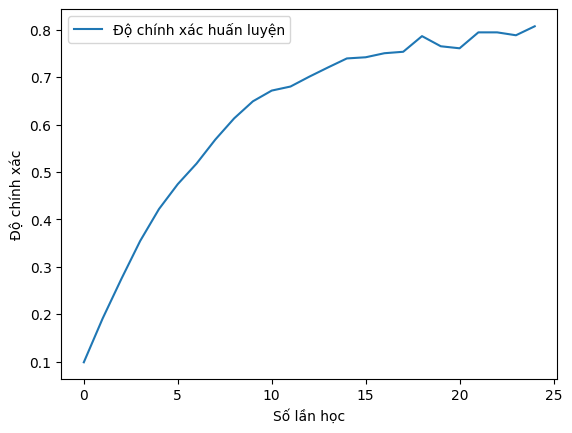

In [29]:
plt.plot(history.history['accuracy'], label="Độ chính xác huấn luyện")
plt.xlabel("Số lần học")
plt.ylabel("Độ chính xác")
plt.legend()
plt.show()

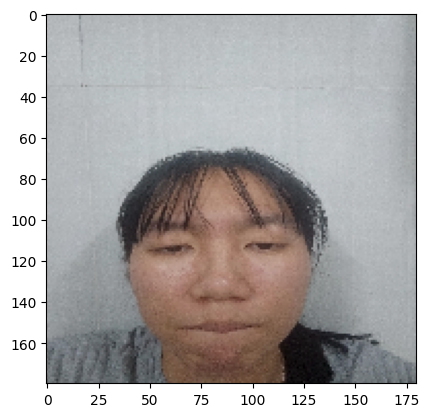

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Người tiên đoán: Trương Gia Kỳ


In [23]:
from keras.utils import load_img
import numpy as np
path ="/content/dataset/Face_RAP001/Trương Gia Kỳ/IMG_20260520_002233_747.jpg"
# Tiên đoán loại s
img = load_img(path, target_size=(180, 180)) # Changed target_size to (180, 180)
plt.imshow(img)
plt.show()
img = np.array(img)
img = img / 255.0
img = img.reshape(1, 180, 180, 3) # Changed reshape to (1, 180, 180, 3)
prediction=np.argmax(model.predict(img))
# Ánh xạ loại tới tên người
class_labels = {v: k for k, v in train_generator.class_indices.items()}
person_name = class_labels[prediction]
print(f"Người tiên đoán: {person_name}")

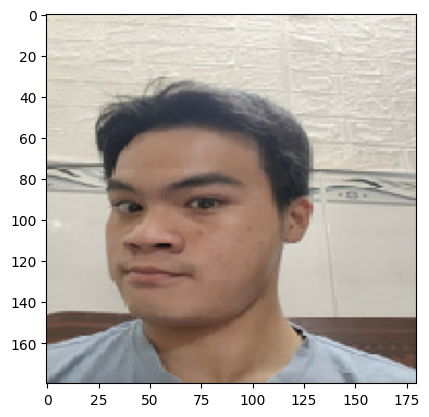

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Người tiên đoán: Nguyễn Quốc Anh


In [24]:
from keras.utils import load_img
import numpy as np
path ="/content/dataset/Face_RAP001/Nguyễn Quốc Anh/z7843845079170_6949f7bd093333fcdfbcc1d3a917e4bc.jpg"
# Tiên đoán loại s
img = load_img(path, target_size=(180, 180)) # Changed target_size to (180, 180)
plt.imshow(img)
plt.show()
img = np.array(img)
img = img / 255.0
img = img.reshape(1, 180, 180, 3) # Changed reshape to (1, 180, 180, 3)
prediction=np.argmax(model.predict(img))
# Ánh xạ loại tới tên người
class_labels = {v: k for k, v in train_generator.class_indices.items()}
person_name = class_labels[prediction]
print(f"Người tiên đoán: {person_name}")

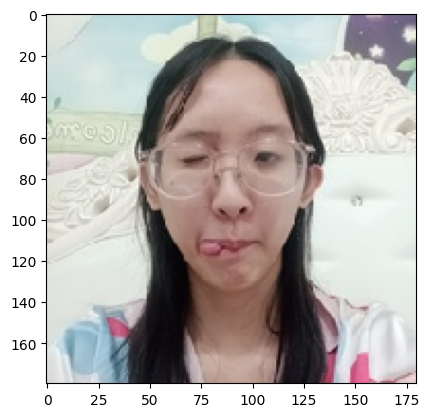

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Người tiên đoán: Nguyễn Phương Mai


In [25]:
from keras.utils import load_img
import numpy as np
path ="/content/dataset/Face_RAP001/Nguyễn Phương Mai/IMG_20260519_233228.jpg"
# Tiên đoán loại s
img = load_img(path, target_size=(180, 180)) # Changed target_size to (180, 180)
plt.imshow(img)
plt.show()
img = np.array(img)
img = img / 255.0
img = img.reshape(1, 180, 180, 3) # Changed reshape to (1, 180, 180, 3)
prediction=np.argmax(model.predict(img))
# Ánh xạ loại tới tên người
class_labels = {v: k for k, v in train_generator.class_indices.items()}
person_name = class_labels[prediction]
print(f"Người tiên đoán: {person_name}")

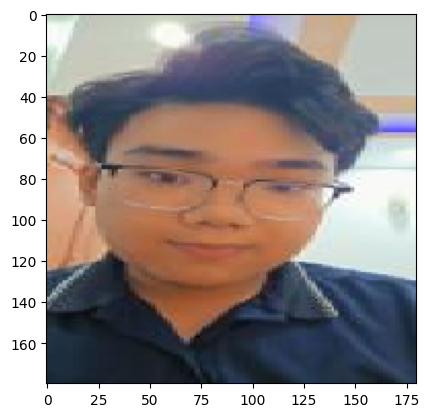

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Người tiên đoán: Trần Hiếu Thiện


In [26]:
from keras.utils import load_img
import numpy as np
path ="/content/dataset/Face_RAP001/Trần Hiếu Thiện/b4cd4a54d838b775e7b437d73f5b37c9_0.jpg"
# Tiên đoán loại s
img = load_img(path, target_size=(180, 180)) # Changed target_size to (180, 180)
plt.imshow(img)
plt.show()
img = np.array(img)
img = img / 255.0
img = img.reshape(1, 180, 180, 3) # Changed reshape to (1, 180, 180, 3)
prediction=np.argmax(model.predict(img))
# Ánh xạ loại tới tên người
class_labels = {v: k for k, v in train_generator.class_indices.items()}
person_name = class_labels[prediction]
print(f"Người tiên đoán: {person_name}")

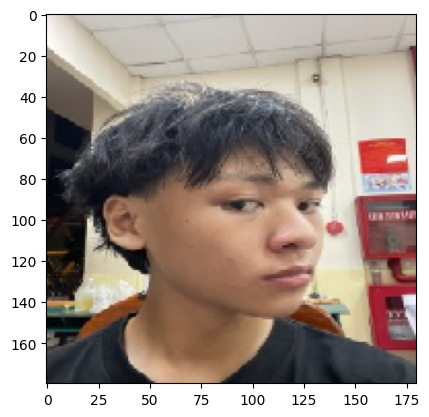

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Người tiên đoán: Trần Hoài Trọng


In [27]:
from keras.utils import load_img
import numpy as np
path ="/content/dataset/Face_RAP001/Trần Hoài Trọng/IMG_8760.jpg"
# Tiên đoán loại s
img = load_img(path, target_size=(180, 180)) # Changed target_size to (180, 180)
plt.imshow(img)
plt.show()
img = np.array(img)
img = img / 255.0
img = img.reshape(1, 180, 180, 3) # Changed reshape to (1, 180, 180, 3)
prediction=np.argmax(model.predict(img))
# Ánh xạ loại tới tên người
class_labels = {v: k for k, v in train_generator.class_indices.items()}
person_name = class_labels[prediction]
print(f"Người tiên đoán: {person_name}")